In [1]:
# Görev 1: 
# Kendi Value sınıfını yaz, toplama ve çarpma ile başla. 
# Her yeni Value, kendisini üreten Value'ları ve hangi işlemden çıktığını saklasın. 

class Value:
    def __init__(self, data, elements=(), ops="", label=''):
        self.data = data
        self.elements = elements
        self.ops = ops
        self.label = label

        self.grad = 0.0
    
    def __repr__(self):
        return f"{self.data}"

    def __add__(self, other):
        # görev 2'deki h eklemek için
        other = other if isinstance(other, Value) else Value(other)

        return Value(self.data + other.data, (self, other), "add")
    
    def __mul__(self, other):
        # görev 2'deki h eklemek için
        other = other if isinstance(other, Value) else Value(other)

        return Value(self.data * other.data, (self, other), "mul")
    

    def tanh(self):
        import math
        x = self.data 
        tan_output = (math.exp(2*x) - 1) / (math.exp(2*x) + 1)
        return Value(data=tan_output, elements=(self, ), ops="tanh")

a = Value(-3.0, label='a')
b = Value(2.0, label='b')
c = Value(10.0, label='c')
e = a*b; e.label='e'
d = e+c; d.label='d'
f = Value(-2.0, label='f')
L = f * d; L.label = 'L'


print(f"e = a*b ->   {a.data} + {b.data} = {a * b}")
print(f"d = e+c ->   {e.data} + {c.data} = {e + c}")
print(f"L = f*d ->   {f.data} * {d.data} = {f * d}")

e = a*b ->   -3.0 + 2.0 = -6.0
d = e+c ->   -6.0 + 10.0 = 4.0
L = f*d ->   -2.0 * 4.0 = -8.0


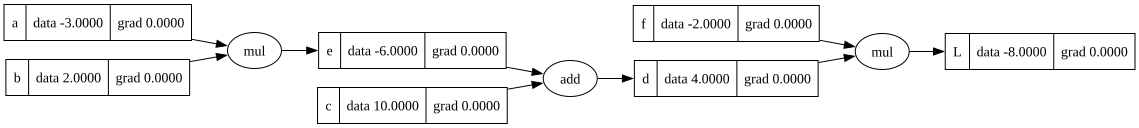

In [2]:
# görselleştirme

from graphviz import Digraph

def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v.elements:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root, format='svg', rankdir='LR'):
    """
    format: png | svg | ...
    rankdir: TB (top to bottom graph) | LR (left to right)
    """
    assert rankdir in ['LR', 'TB']
    nodes, edges = trace(root)
    dot = Digraph(format=format, graph_attr={'rankdir': rankdir})
    
    for n in nodes:
        dot.node(name=str(id(n)), label="{%s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
        
        if n.ops:
            dot.node(name=str(id(n)) + n.ops, label=n.ops)
            dot.edge(str(id(n)) + n.ops, str(id(n)))
    
    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2.ops)
    
    return dot

draw_dot(L)


In [3]:
# Görev 2:
# Otomatikleştirmeden önce gradient'leri videodaki iki örnekte elle doldur: 
    # Görev 2.1 - önce basit ifade 
    # Görev 2.2 - sonra tek bir neuron. 
        # Neuron örneğinde tanh'ı Value'ya ekleyeceksin.

In [4]:
# Görev 2:
    # Görev 2.1 - önce basit ifade 


def find_L(a,b,c,f, d=None, e=None):
    # d+h ve e+h pass ediyoruz, ama override ediliyo 
        # e = a*b
        # d = c+e tarafından
    # ondan bu if-else blokları
    if d is None and e is None:
        e = a*b
        d = c+e
        L = f*d
        return L
    else:
        if d is not None:
            e = a*b
            d = d
            L = f*d
            return L
        if e is not None:
            e = e
            d = c+e
            L = f*d
            return L

def find_all_numerical_derivatives(a,b,c,d,e,f, h=0.01):
    # f'(x) = ( f(x+h) - f(x) ) / h  
    # f(x)  = ( (a * b) + c ) * f
    # f(x+h) = ?
        # neye göre türev alıcaksan ona + h eklicen
        # örnekler:
            # 𝑑𝑓 / 𝑑𝑎 
                    # => f(x+h)'ta, "a" yerine "a+h" de
                # ( [( ((a+h) * b) + c ) * f] - [( (a * b) + c ) * f] ) / h
                #           f(x+h)            -             f(x)


            # 𝑑L / 𝑑b 
                    # => f(x+h)'ta, "b" yerine "b+h" de
                # ( [( (a * (b+h)) + c ) * f] - [( (a * b) + c ) * f] ) / h


            # 𝑑L / 𝑑c 
                    # => f(x+h)'ta, "c" yerine "c+h" de
                # ( [( (a * b) + (c+h) ) * f] - [( (a * b) + c ) * f] ) / h


            # 𝑑L / 𝑑d 
                    # => f(x+h)'ta, "d" yerine "d+h" de
                    # L'nin d'ye göre formülü: L = f * d
                # ( [f * (d+h)] - [f * d] ) / h
                    # AÇILMIŞ HALİ: d demek ((a * b) + c) demektir.
                # ( [ ( ((a * b) + c) + h ) * f ] - [ ( ((a * b) + c) ) * f ] ) / h


            # 𝑑L / 𝑑e 
                    # => f(x+h)'ta, "e" yerine "e+h" de
                    # L'nin e'ye göre formülü: L = f * (c + e)
                # ( [f * (c + (e+h))] - [f * (c + e)] ) / h
                    # AÇILMIŞ HALİ: e demek (a * b) demektir.
                # ( [ ( ((a * b) + h) + c ) * f ] - [ ( ((a * b) + c) ) * f ] ) / h


            # 𝑑L / 𝑑f 
                    # => f(x+h)'ta, "f" yerine "f+h" de
                # ( [( (a * b) + c ) * (f+h)] - [( (a * b) + c ) * f] ) / h

            # 𝑑L / 𝑑L 
                # ztn kendisiyle bölüyoruz ondan 1
                # matematiksel olarak:
                    # ( f(x) + h - f(x) ) / h
                    # h / h = 1
       
    print("--- NUMERICAL DERIVATIVE İLE HESAPLAMA ---")

    # 𝑑L / 𝑑𝑎 
    L1 = find_L(a,b,c,f)
    L2 = find_L(a+h,b,c,f)
    print(f"dL/da = {(L2.data - L1.data) / h}")
    a.grad = (L2.data - L1.data) / h

    # 𝑑L / 𝑑b 
    L1 = find_L(a,b,c,f)
    L2 = find_L(a,b+h,c,f)
    print(f"dL/db = {(L2.data - L1.data) / h}")
    b.grad = (L2.data - L1.data) / h

    # 𝑑L / 𝑑c 
    L1 = find_L(a,b,c,f)
    L2 = find_L(a,b,c+h,f)
    print(f"dL/dc = {(L2.data - L1.data) / h}")
    c.grad = (L2.data - L1.data) / h

    # 𝑑L / 𝑑d 
    L1 = find_L(a,b,c,f)
    L2 = find_L(a,b,c,f, d=d+h)   # Burada d'yi dışarıdan özel verip içeridekini ezdik
    print(f"dL/dd = {(L2.data - L1.data) / h}")
    d.grad = (L2.data - L1.data) / h

    # 𝑑L / 𝑑e 
    L1 = find_L(a,b,c,f)
    L2 = find_L(a,b,c,f, e=e+h)   # Burada e'yi dışarıdan özel verip içeridekini ezdik
    print(f"dL/de = {(L2.data - L1.data) / h}")
    e.grad = (L2.data - L1.data) / h

    # 𝑑L / 𝑑f 
    L1 = find_L(a,b,c,f)
    L2 = find_L(a,b,c,f+h)
    print(f"dL/df = {(L2.data - L1.data) / h}")
    f.grad = (L2.data - L1.data) / h

    # 𝑑L / 𝑑L 
    L1 = find_L(a,b,c,f)
    L2 = L1 + h 
    print(f"dL/dL = {(L2.data - L1.data) / h}\n")
    L.grad = (L2.data - L1.data) / h


def find_all_chain_rule_derivatives(a,b,c,d,e,f):
    # 1. 𝑑L / 𝑑L 
        # İSPAT: L'nin kendisine göre değişimi
        # ( (L + h) - L ) / h  =>  h / h = 1.0
    dL_dL = 1.0


    # 2. 𝑑L / 𝑑f
        # Ana formül: L = f * d
        # İSPAT: ( ((f+h)*d) - (f*d) ) / h 
        #      => (f*d + h*d - f*d) / h 
        #      => (h*d) / h = d
    dL_df = d.data


    # 3. 𝑑L / 𝑑d
        # Ana formül: L = f * d
        # İSPAT: ( (f*(d+h)) - (f*d) ) / h 
        #      => (f*d + f*h - f*d) / h 
        #      => (f*h) / h = f
    dL_dd = f.data


    # 4. 𝑑L / 𝑑c
        # Hedef formül: d = c + e  (d'nin c'ye göre *yerel* türevi)
        # İSPAT: ( ((c+h)+e) - (c+e) ) / h 
        #      => (c + h + e - c - e) / h 
        #      => h / h = 1.0
    dd_dc = 1.0
    dL_dc = dL_dd * dd_dc
        # Zincir: dL/dc = dL/dd * dd/dc


    # 5. 𝑑L / 𝑑e
        # Hedef formül: d = c + e  (d'nin e'ye göre *yerel* türevi)
        # İSPAT: ( (c+(e+h)) - (c+e) ) / h 
        #      => (c + e + h - c - e) / h 
        #      => h / h = 1.0
    dd_de = 1.0
    dL_de = dL_dd * dd_de
        # Zincir: dL/de = dL/dd * dd/de


    # 6. 𝑑L / 𝑑a
        # Hedef formül: e = a * b  (e'nin a'ya göre *yerel* türevi)
        # İSPAT: ( ((a+h)*b) - (a*b) ) / h 
        #      => (a*b + h*b - a*b) / h 
        #      => (h*b) / h = b
    de_da = b.data
    dL_da = dL_de * de_da
        # Zincir: dL/da = dL/de * de/da


    # 7. 𝑑L / 𝑑b
        # Hedef formül: e = a * b  (e'nin b'ye göre *yerel* türevi)
        # İSPAT: ( (a*(b+h)) - (a*b) ) / h 
        #      => (a*b + a*h - a*b) / h 
        #      => (a*h) / h = a
    de_db = a.data
    dL_db = dL_de * de_db
        # Zincir: dL/db = dL/de * de/db
    

    # GRAD'LARINI GÜNCELLE
    a.grad = dL_da
    b.grad = dL_db
    c.grad = dL_dc
    d.grad = dL_dd
    e.grad = dL_de
    f.grad = dL_df
    L.grad = dL_dL


    print("--- CHAIN RULE (ZİNCİR KURALI) İLE HESAPLAMA ---")
    print(f"dL/da = dL/de * de/da  =>  {dL_de} * {de_da} = {dL_da}")
    print(f"dL/db = dL/de * de/db  =>  {dL_de} * {de_db} = {dL_db}")
    print(f"dL/dc = dL/dd * dd/dc  =>  {dL_dd} * {dd_dc} = {dL_dc}")
    print(f"dL/dd = {dL_dd}")
    print(f"dL/de = dL/dd * dd/de  =>  {dL_dd} * {dd_de} = {dL_de}")
    print(f"dL/df = {dL_df}")
    print(f"dL/dL = {dL_dL}")


def step(a,b,c,d,e,f, step=0.01):
    a.data += step * a.grad
    b.data += step * b.grad
    c.data += step * c.grad
    #d ve e ztn a,b,c,f ile oluşuyor... ondan gerek yok onlara
    f.data += step * f.grad

    L = find_L(a,b,c,f)

    print(f"\nValue of L after step: {L.data}")

find_all_numerical_derivatives(a,b,c,d,e,f, h=0.01)

find_all_chain_rule_derivatives(a,b,c,d,e,f)

step(a,b,c,d,e,f,step=0.01)

--- NUMERICAL DERIVATIVE İLE HESAPLAMA ---
dL/da = -3.9999999999999147
dL/db = 5.999999999999872
dL/dc = -1.9999999999999574
dL/dd = -1.9999999999999574
dL/de = -1.9999999999999574
dL/df = 4.0000000000000036
dL/dL = 0.9999999999999787

--- CHAIN RULE (ZİNCİR KURALI) İLE HESAPLAMA ---
dL/da = dL/de * de/da  =>  -2.0 * 2.0 = -4.0
dL/db = dL/de * de/db  =>  -2.0 * -3.0 = 6.0
dL/dc = dL/dd * dd/dc  =>  -2.0 * 1.0 = -2.0
dL/dd = -2.0
dL/de = dL/dd * dd/de  =>  -2.0 * 1.0 = -2.0
dL/df = 4.0
dL/dL = 1.0

Value of L after step: -7.286496


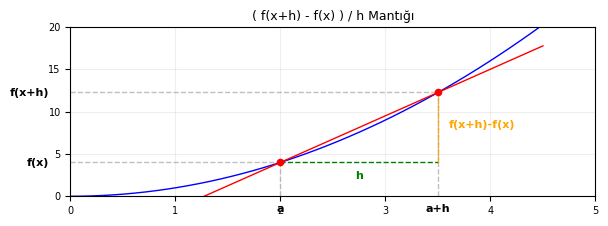

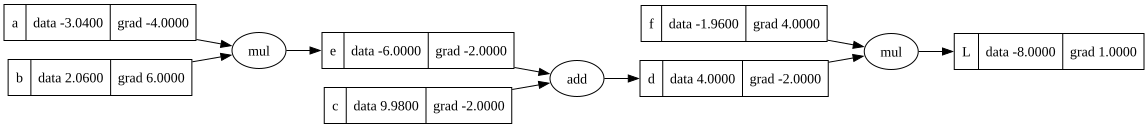

In [5]:
# görselleştirme

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display, HTML

def tam_kapsamli_tumu_bir_arada(a_val=-3.0, b_val=2.0, c_val=10.0, f_val=-2.0):
    # Değerleri hesapla (Sayıları HTML içine gömmek için)
    e_val = a_val * b_val       # -6.0
    d_val = c_val + e_val       # 4.0
    # L = d_val * f_val         # -8.0

    # 1. GRAFİK KISMI
    x_vals = np.linspace(0, 5, 50)
    y_vals = x_vals**2

    plt.figure(figsize=(6, 2.2)) 
    plt.plot(x_vals, y_vals, label="f(x)", color="blue", linewidth=1)

    x, h = 2.0, 1.5
    x_plus_h = x + h
    f_x, f_x_plus_h = x**2, x_plus_h**2

    plt.scatter([x, x_plus_h], [f_x, f_x_plus_h], color="red", zorder=5, s=20)
    plt.vlines([x, x_plus_h], 0, [f_x, f_x_plus_h], linestyle="dashed", color="gray", alpha=0.5, linewidth=1)
    plt.hlines([f_x, f_x_plus_h], 0, [x, x_plus_h], linestyle="dashed", color="gray", alpha=0.5, linewidth=1)

    plt.plot([x, x_plus_h], [f_x, f_x], linestyle="--", color="green", linewidth=1) 
    plt.plot([x_plus_h, x_plus_h], [f_x, f_x_plus_h], linestyle="--", color="orange", linewidth=1) 

    slope = (f_x_plus_h - f_x) / h
    plt.plot([x-1, x_plus_h+1], [f_x - slope*1, f_x_plus_h + slope*1], color="red", linewidth=1)

    plt.text(x, -1.8, "a", ha="center", fontweight='bold', fontsize=8)
    plt.text(x_plus_h, -1.8, "a+h", ha="center", fontweight='bold', fontsize=8)
    plt.text(-0.2, f_x, "f(x)", va="center", ha="right", fontweight='bold', fontsize=8)
    plt.text(-0.2, f_x_plus_h, "f(x+h)", va="center", ha="right", fontweight='bold', fontsize=8)
    plt.text(x + h/2, f_x - 2, "h", color="green", ha="center", fontweight='bold', fontsize=8)
    plt.text(x_plus_h + 0.1, f_x + (f_x_plus_h-f_x)/2, "f(x+h)-f(x)", color="orange", fontsize=8, fontweight='bold')

    plt.title("( f(x+h) - f(x) ) / h Mantığı", fontsize=9, pad=5)
    plt.xlim(0, 5)
    plt.ylim(0, 20)
    plt.xticks(fontsize=7)
    plt.yticks(fontsize=7)
    plt.grid(True, alpha=0.2)
    plt.tight_layout(pad=0.5)
    plt.show()

    # 2. HTML KISMI (Sayısal Türev + Zincir Kuralı + Sonuç Notu)
    html_content = f"""
    <div style="font-family: 'Georgia', serif; background-color: #fff; color: #000; padding: 12px; border: 1px solid #ddd; border-radius: 5px; line-height: 1.3; font-size: 11px; max-width: 800px; margin: 0 auto;">
        
        <!-- BÖLÜM 1: NUMERICAL DERIVATIVE -->
        <div style="font-family: 'Consolas', monospace; font-size: 10px; background-color: #f1f1f1; padding: 6px; margin-bottom: 10px; border-left: 3px solid #555;">
            <b style="font-size: 11px;">1. SAYISAL TÜREV (NUMERICAL DERIVATIVE)</b><br>
            f'(x) = ( f(x+h) - f(x) ) / h &nbsp;&nbsp;|&nbsp;&nbsp; f(x) = ( (a * b) + c ) * f <br>
            <span style="font-style: italic;">=> Neye göre türev alıcaksan ona +h eklicen</span>
        </div>
        
        <div style="display: flex; justify-content: space-between; margin-bottom: 20px;">
            <div style="width: 48%;">
                <div style="margin-bottom: 10px;">
                    <b>𝑑𝑓/𝑑𝑎:</b> <i style="color:#444;">"a" yerine "a+h"</i><br>
                    <span style="font-family: monospace; font-size:10px;">( [( ((<b style="background:#ffcccc; padding:0 2px;">a+h</b>) * b) + c ) * f] - [( (a * b) + c ) * f] ) / h</span>
                </div>
                <div style="margin-bottom: 10px;">
                    <b>𝑑L/𝑑b:</b> <i style="color:#444;">"b" yerine "b+h"</i><br>
                    <span style="font-family: monospace; font-size:10px;">( [( (a * (<b style="background:#ffcccc; padding:0 2px;">b+h</b>)) + c ) * f] - [( (a * b) + c ) * f] ) / h</span>
                </div>
                <div style="margin-bottom: 10px;">
                    <b>𝑑L/𝑑c:</b> <i style="color:#444;">"c" yerine "c+h"</i><br>
                    <span style="font-family: monospace; font-size:10px;">( [( (a * b) + (<b style="background:#ffcccc; padding:0 2px;">c+h</b>) ) * f] - [( (a * b) + c ) * f] ) / h</span>
                </div>
            </div>

            <div style="width: 50%;">
                <div style="margin-bottom: 10px;">
                    <b>𝑑L/𝑑d:</b> <i style="color:#444;">"d" yerine "d+h". (Açılımı: d = a*b+c)</i><br>
                    <span style="font-family: monospace; font-size:10px;">( [ ( ((a * b) + c) <b style="background:#ffcccc; padding:0 2px;">+ h</b> ) * f ] - [ ( ((a * b) + c) ) * f ] ) / h</span>
                </div>
                <div style="margin-bottom: 10px;">
                    <b>𝑑L/𝑑e:</b> <i style="color:#444;">"e" yerine "e+h". (Açılımı: e = a*b)</i><br>
                    <span style="font-family: monospace; font-size:10px;">( [ ( ((a * b) <b style="background:#ffcccc; padding:0 2px;">+ h</b>) + c ) * f ] - [ ( ((a * b) + c) ) * f ] ) / h</span>
                </div>
                <div style="margin-bottom: 10px;">
                    <b>𝑑L/𝑑f:</b> <i style="color:#444;">"f" yerine "f+h"</i><br>
                    <span style="font-family: monospace; font-size:10px;">( [( (a * b) + c ) * (<b style="background:#ffcccc; padding:0 2px;">f+h</b>)] - [( (a * b) + c ) * f] ) / h</span>
                </div>
            </div>
        </div>

        <hr style="border: 0; border-top: 1px dashed #ccc; margin: 15px 0;">

        <!-- BÖLÜM 2: CHAIN RULE -->
        <div style="font-family: 'Consolas', monospace; font-size: 10px; background-color: #e8f4f8; padding: 6px; margin-bottom: 15px; border-left: 3px solid #007acc;">
            <b style="font-size: 11px;">2. ZİNCİR KURALI (CHAIN RULE) İSPATLARI</b><br>
            İleri Yönlü Adımlar: &nbsp; 
            <span style="background-color: #fff; padding: 1px 4px; border-radius: 3px;">e = a*b ({e_val})</span> &nbsp;|&nbsp; 
            <span style="background-color: #fff; padding: 1px 4px; border-radius: 3px;">d = c+e ({d_val})</span> &nbsp;|&nbsp; 
            <span style="background-color: #fff; padding: 1px 4px; border-radius: 3px;">L = f*d ({f_val}*{d_val})</span> <br>
        </div>

        <div style="display: flex; justify-content: space-between;">
            
            <div style="width: 48%;">
                <div style="margin-bottom: 12px;">
                    <b>1. 𝑑L/𝑑L:</b> <i style="color:#444;">(L+h - L) / h => h/h = 1.0</i><br>
                    <span style="font-family: monospace; font-size:11px; background-color: #f1f1f1; padding: 2px 4px; font-weight: bold; border-radius: 3px;">dL/dL = 1.0</span>
                </div>
                <div style="margin-bottom: 12px;">
                    <b>2. 𝑑L/𝑑f:</b> <i style="color:#444;">L = f*d => (f*d + h*d - f*d) / h => <b style="color:black">d</b></i><br>
                    <span style="font-family: monospace; font-size:11px; background-color: #f1f1f1; padding: 2px 4px; font-weight: bold; border-radius: 3px;">dL/df = d = {d_val}</span>
                </div>
                <div style="margin-bottom: 12px;">
                    <b>3. 𝑑L/𝑑d:</b> <i style="color:#444;">L = f*d => (f*d + f*h - f*d) / h => <b style="color:black">f</b></i><br>
                    <span style="font-family: monospace; font-size:11px; background-color: #f1f1f1; padding: 2px 4px; font-weight: bold; border-radius: 3px;">dL/dd = f = {f_val}</span>
                </div>
                <div style="margin-bottom: 12px;">
                    <b>4. 𝑑L/𝑑c:</b> <i style="color:#444;">d = c+e => ((c+h)+e - (c+e)) / h => <b style="color:black">1.0</b></i><br>
                    <span style="font-family: monospace; font-size:10px; color:#555;">dL/dc = dL/dd * dd/dc</span><br>
                    <span style="font-family: monospace; font-size:11px; background-color: #e8f4f8; padding: 2px 4px; font-weight: bold; border-radius: 3px;">dL/dc = {f_val} * 1.0 = {f_val * 1.0}</span>
                </div>
            </div>

            <div style="width: 50%;">
                <div style="margin-bottom: 12px;">
                    <b>5. 𝑑L/𝑑e:</b> <i style="color:#444;">d = c+e => (c+(e+h) - (c+e)) / h => <b style="color:black">1.0</b></i><br>
                    <span style="font-family: monospace; font-size:10px; color:#555;">dL/de = dL/dd * dd/de</span><br>
                    <span style="font-family: monospace; font-size:11px; background-color: #e8f4f8; padding: 2px 4px; font-weight: bold; border-radius: 3px;">dL/de = {f_val} * 1.0 = {f_val * 1.0}</span>
                </div>
                <div style="margin-bottom: 12px;">
                    <b>6. 𝑑L/𝑑a:</b> <i style="color:#444;">e = a*b => (a*b + h*b - a*b) / h => <b style="color:black">b</b></i><br>
                    <span style="font-family: monospace; font-size:10px; color:#555;">dL/da = dL/de * de/da</span><br>
                    <span style="font-family: monospace; font-size:11px; background-color: #e8f4f8; padding: 2px 4px; font-weight: bold; border-radius: 3px;">dL/da = {f_val * 1.0} * {b_val} = {(f_val * 1.0) * b_val}</span>
                </div>
                <div style="margin-bottom: 12px;">
                    <b>7. 𝑑L/𝑑b:</b> <i style="color:#444;">e = a*b => (a*b + a*h - a*b) / h => <b style="color:black">a</b></i><br>
                    <span style="font-family: monospace; font-size:10px; color:#555;">dL/db = dL/de * de/db</span><br>
                    <span style="font-family: monospace; font-size:11px; background-color: #e8f4f8; padding: 2px 4px; font-weight: bold; border-radius: 3px;">dL/db = {f_val * 1.0} * {a_val} = {(f_val * 1.0) * a_val}</span>
                </div>
            </div>
            
        </div>
        
        <hr style="border: 0; border-top: 1px dashed #ccc; margin: 15px 0;">
        
        <!-- BÖLÜM 3: ÖNEMLİ NOT -->
        <div style="font-family: 'Consolas', monospace; font-size: 11px; background-color: #fffbe6; padding: 8px; border-left: 3px solid #f0ad4e; color: #8a6d3b;">
            <b>💡 Madem h sonucu etkilemiyor... Neden numerical derivative'de kullandık?</b><br>
            Çünkü, numerical derivative'in bir elemanı... mecburen ona da bir değer vericen.
        </div>

    </div>
    """
    display(HTML(html_content))

tam_kapsamli_tumu_bir_arada(-3.0, 2.0, 10.0, -2.0)
draw_dot(L)


In [6]:
# Görev 2:
    # Görev 2.2 - sonra tek bir neuron. 
        # Neuron örneğinde tanh'ı Value'ya ekleyeceksin.


# inputs x1, x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1, w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
b = Value(6.8813735870195432, label='b')

x1w1 = x1 * w1; x1w1.label = 'x1*w1'
x2w2 = x2 * w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
output = n.tanh(); output.label = 'output'
draw_dot(output)



def find_neuron_chain_rule_derivatives(x1, w1, x2, w2, b, x1w1, x2w2, x1w1x2w2, n, output):
    # 1. 𝑑output / 𝑑output 
        # İSPAT: Kendisine göre değişimi
        # ( (output + h) - output ) / h  =>  h / h = 1.0
    d_output = 1.0


    # 2. 𝑑output / 𝑑n
        # Ana formül: output = tanh(n)
        # İSPAT (Kalkülüs Kuralı): tanh(x)'in türevi her zaman (1 - tanh(x)^2) dir.
        # Bizim output'umuz zaten tanh(n) olduğu için: (1 - output^2)
    dn_yerel = 1.0 - (output.data ** 2)
    dn = d_output * dn_yerel
        # Zincir: d_output/dn = d_output/d_output * d_output/dn


    # 3. 𝑑output / 𝑑b
        # Hedef formül: n = x1w1x2w2 + b
        # İSPAT (Yerel): ( (x1w1x2w2 + (b+h)) - (x1w1x2w2 + b) ) / h => h / h = 1.0
    db_yerel = 1.0
    db = dn * db_yerel
        # Zincir: d_output/db = d_output/dn * dn/db


    # 4. 𝑑output / 𝑑x1w1x2w2
        # Hedef formül: n = x1w1x2w2 + b
        # İSPAT (Yerel): ( ((x1w1x2w2+h) + b) - (x1w1x2w2 + b) ) / h => h / h = 1.0
    dx1w1x2w2_yerel = 1.0
    dx1w1x2w2 = dn * dx1w1x2w2_yerel


    # 5. 𝑑output / 𝑑x1w1
        # Hedef formül: x1w1x2w2 = x1w1 + x2w2
        # İSPAT (Yerel): ( ((x1w1+h) + x2w2) - (x1w1 + x2w2) ) / h => h / h = 1.0
    dx1w1_yerel = 1.0
    dx1w1 = dx1w1x2w2 * dx1w1_yerel


    # 6. 𝑑output / 𝑑x2w2
        # Hedef formül: x1w1x2w2 = x1w1 + x2w2
        # İSPAT (Yerel): ( (x1w1 + (x2w2+h)) - (x1w1 + x2w2) ) / h => h / h = 1.0
    dx2w2_yerel = 1.0
    dx2w2 = dx1w1x2w2 * dx2w2_yerel


    # 7. 𝑑output / 𝑑w1
        # Hedef formül: x1w1 = x1 * w1
        # İSPAT (Yerel): ( (x1 * (w1+h)) - (x1*w1) ) / h => (x1*h)/h = x1
    dw1_yerel = x1.data
    dw1 = dx1w1 * dw1_yerel


    # 8. 𝑑output / 𝑑x1
        # Hedef formül: x1w1 = x1 * w1
        # İSPAT (Yerel): ( ((x1+h) * w1) - (x1*w1) ) / h => (w1*h)/h = w1
    dx1_yerel = w1.data
    dx1 = dx1w1 * dx1_yerel


    # 9. 𝑑output / 𝑑w2
        # Hedef formül: x2w2 = x2 * w2
        # İSPAT (Yerel): ( (x2 * (w2+h)) - (x2*w2) ) / h => (x2*h)/h = x2
    dw2_yerel = x2.data
    dw2 = dx2w2 * dw2_yerel


    # 10. 𝑑output / 𝑑x2
        # Hedef formül: x2w2 = x2 * w2
        # İSPAT (Yerel): ( ((x2+h) * w2) - (x2*w2) ) / h => (w2*h)/h = w2
    dx2_yerel = w2.data
    dx2 = dx2w2 * dx2_yerel


    # --- NESNELERİN GRAD DEĞERLERİNİ GÜNCELLE ---
    output.grad = d_output
    n.grad = dn
    b.grad = db
    x1w1x2w2.grad = dx1w1x2w2
    x1w1.grad = dx1w1
    x2w2.grad = dx2w2
    w1.grad = dw1
    x1.grad = dx1
    w2.grad = dw2
    x2.grad = dx2


draw_dot(output)

# Nöronu çalıştırıp gradyanları dolduralım
find_neuron_chain_rule_derivatives(x1, w1, x2, w2, b, x1w1, x2w2, x1w1x2w2, n, output)


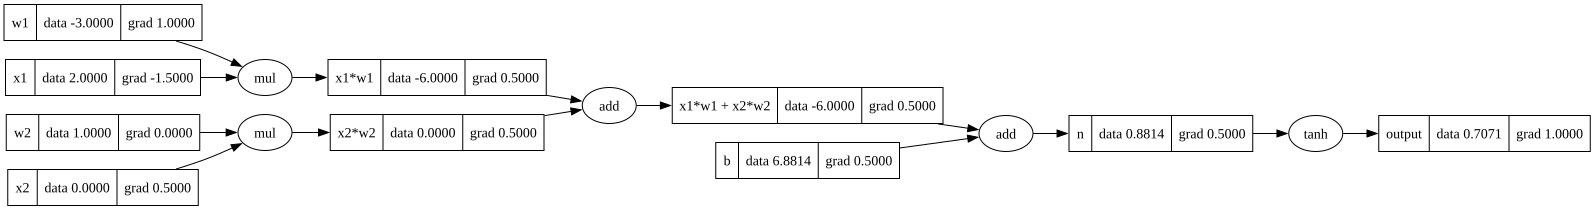

In [7]:
# görselleştirme
from IPython.display import display, HTML

def noron_zincir_kurali_gorsel():
    html_content = """
    <div style="font-family: 'Georgia', serif; background-color: #fff; color: #000; padding: 12px; border: 1px solid #ddd; border-radius: 5px; line-height: 1.4; font-size: 11px; max-width: 850px; margin: 0 auto;">
        
        <!-- BAŞLIK BÖLÜMÜ -->
        <div style="font-family: 'Consolas', monospace; font-size: 11px; background-color: #e8f4f8; padding: 8px; margin-bottom: 15px; border-left: 3px solid #007acc;">
            <b style="font-size: 12px;">TEK BİR NÖRON İÇİN ZİNCİR KURALI İSPATLARI</b><br>
            <span style="color: #444;">İleri Yönlü Adımlar (Forward Pass):</span><br>
            <span style="background-color: #fff; padding: 1px 4px; border-radius: 3px;">1) Çarpımlar: x1w1 = x1*w1, x2w2 = x2*w2</span> &nbsp; | &nbsp;
            <span style="background-color: #fff; padding: 1px 4px; border-radius: 3px;">2) Toplamlar: n = (x1w1 + x2w2) + b</span> &nbsp; | &nbsp;
            <span style="background-color: #fff; padding: 1px 4px; border-radius: 3px;">3) Aktivasyon: output = tanh(n)</span>
        </div>
        
        <div style="display: flex; justify-content: space-between;">
            
            <!-- SOL KOLON: Aktivasyon ve Toplamalar (En Kolayları) -->
            <div style="width: 48%;">
                
                <div style="margin-bottom: 14px;">
                    <b>1. 𝑑(out)/𝑑(out):</b> <i style="color:#444;">Kendisine göre değişim</i><br>
                    <span style="font-family: monospace; font-size:10px; color:#555;">İSPAT: ( (out + h) - out ) / h &nbsp;=>&nbsp; <b style="color:black; font-size:11px;">1.0</b></span>
                </div>
                
                <div style="margin-bottom: 14px;">
                    <b>2. 𝑑(out)/𝑑n:</b> <i style="color:#444;">Aktivasyon formülü: tanh(n)</i><br>
                    <span style="font-family: monospace; font-size:10px; color:#555;">İSPAT (Kalkülüs Kuralı): tanh(x)'in türevi <b style="color:black; font-size:11px;">(1 - tanh(x)²)</b> dir.</span><br>
                    <span style="font-family: monospace; font-size:11px; background-color: #e8f4f8; padding: 2px 4px; font-weight: bold; border-radius: 3px;">Zincir: d(out)/dn = 1.0 * (1 - out²)</span>
                </div>
                
                <div style="margin-bottom: 14px;">
                    <b>3. 𝑑(out)/𝑑b:</b> <i style="color:#444;">Toplama: n = x1w1x2w2 + b</i><br>
                    <span style="font-family: monospace; font-size:10px; color:#555;">İSPAT (Yerel): ( (x1w1x2w2 + (b+h)) - n ) / h &nbsp;=>&nbsp; <b style="color:black; font-size:11px;">1.0</b></span><br>
                    <span style="font-family: monospace; font-size:11px; background-color: #e8f4f8; padding: 2px 4px; font-weight: bold; border-radius: 3px;">Zincir: dn_db = dn * 1.0</span>
                </div>

                <div style="margin-bottom: 14px;">
                    <b>4. 𝑑(out)/𝑑(x1w1x2w2):</b> <i style="color:#444;">Toplama: n = x1w1x2w2 + b</i><br>
                    <span style="font-family: monospace; font-size:10px; color:#555;">İSPAT (Yerel): ( ((x1w1x2w2+h) + b) - n ) / h &nbsp;=>&nbsp; <b style="color:black; font-size:11px;">1.0</b></span><br>
                    <span style="font-family: monospace; font-size:11px; background-color: #e8f4f8; padding: 2px 4px; font-weight: bold; border-radius: 3px;">Zincir: dn_dx1w1x2w2 = dn * 1.0</span>
                </div>
                
                <div style="margin-bottom: 14px;">
                    <b>5-6. 𝑑(out)/𝑑(x1w1) ve 𝑑(x2w2):</b> <i style="color:#444;">Toplama: x1w1 + x2w2</i><br>
                    <span style="font-family: monospace; font-size:10px; color:#555;">İSPAT (Yerel): +h eklendiğinde sadece h artar &nbsp;=>&nbsp; <b style="color:black; font-size:11px;">1.0</b></span><br>
                    <span style="font-family: monospace; font-size:11px; background-color: #e8f4f8; padding: 2px 4px; font-weight: bold; border-radius: 3px;">Zincir: dx1w1 = dx1w1x2w2 * 1.0</span>
                </div>

            </div>

            <!-- SAĞ KOLON: Çarpımlar (Ağırlıklar ve Girdiler) -->
            <div style="width: 50%;">
                
                <div style="margin-bottom: 14px;">
                    <b style="color: darkred;">💡 ÖNEMLİ NOT: ÇARPIMIN TÜREVİ</b><br>
                    <span style="color: #444;">Toplama işleminde türev her zaman <b>1.0</b> çıkar ve zincirdeki gücü aynen geriye iletiriz. Fakat Çarpma (*) işleminde yerel türev her zaman <b><u style="color:black;">yanındaki katsayıdır!</u></b> Aşağıdaki hesaplamalar buna dayanır.</span>
                </div>

                <div style="margin-bottom: 14px;">
                    <b>7. 𝑑(out)/𝑑w1:</b> <i style="color:#444;">Çarpma: x1w1 = x1 * w1</i><br>
                    <span style="font-family: monospace; font-size:10px; color:#555;">İSPAT (Yerel): ( (x1 * (w1+h)) - x1*w1 ) / h &nbsp;=>&nbsp; <b style="color:black; font-size:11px;">x1</b></span><br>
                    <span style="font-family: monospace; font-size:11px; background-color: #fff9e6; padding: 2px 4px; font-weight: bold; border-radius: 3px; border: 1px solid #f0ad4e;">Zincir: dw1 = dx1w1 * x1.data</span>
                </div>
                
                <div style="margin-bottom: 14px;">
                    <b>8. 𝑑(out)/𝑑x1:</b> <i style="color:#444;">Çarpma: x1w1 = x1 * w1</i><br>
                    <span style="font-family: monospace; font-size:10px; color:#555;">İSPAT (Yerel): ( ((x1+h) * w1) - x1*w1 ) / h &nbsp;=>&nbsp; <b style="color:black; font-size:11px;">w1</b></span><br>
                    <span style="font-family: monospace; font-size:11px; background-color: #fff9e6; padding: 2px 4px; font-weight: bold; border-radius: 3px; border: 1px solid #f0ad4e;">Zincir: dx1 = dx1w1 * w1.data</span>
                </div>
                
                <div style="margin-bottom: 14px;">
                    <b>9. 𝑑(out)/𝑑w2:</b> <i style="color:#444;">Çarpma: x2w2 = x2 * w2</i><br>
                    <span style="font-family: monospace; font-size:10px; color:#555;">İSPAT (Yerel): ( (x2 * (w2+h)) - x2*w2 ) / h &nbsp;=>&nbsp; <b style="color:black; font-size:11px;">x2</b></span><br>
                    <span style="font-family: monospace; font-size:11px; background-color: #fff9e6; padding: 2px 4px; font-weight: bold; border-radius: 3px; border: 1px solid #f0ad4e;">Zincir: dw2 = dx2w2 * x2.data</span>
                </div>
                
                <div style="margin-bottom: 14px;">
                    <b>10. 𝑑(out)/𝑑x2:</b> <i style="color:#444;">Çarpma: x2w2 = x2 * w2</i><br>
                    <span style="font-family: monospace; font-size:10px; color:#555;">İSPAT (Yerel): ( ((x2+h) * w2) - x2*w2 ) / h &nbsp;=>&nbsp; <b style="color:black; font-size:11px;">w2</b></span><br>
                    <span style="font-family: monospace; font-size:11px; background-color: #fff9e6; padding: 2px 4px; font-weight: bold; border-radius: 3px; border: 1px solid #f0ad4e;">Zincir: dx2 = dx2w2 * w2.data</span>
                </div>
                
            </div>
            
        </div>
    </div>
    """
    display(HTML(html_content))

noron_zincir_kurali_gorsel()
# Her şey .grad değerlerine işlendiği için artık grafiği çizdirebilirsin
draw_dot(output)

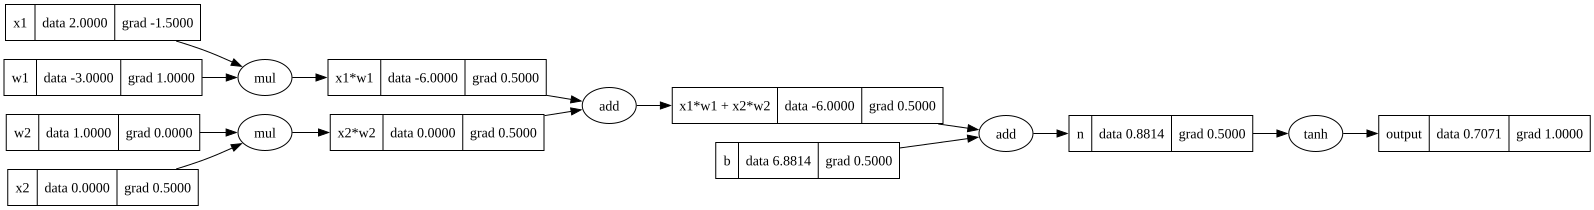

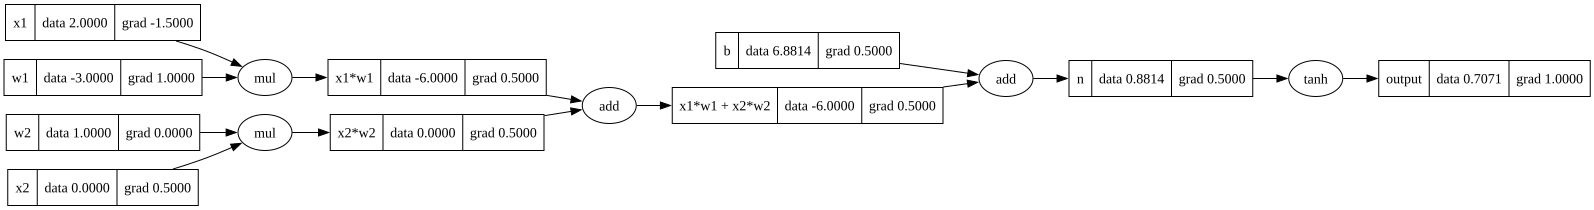

In [8]:
# Görev 3: backward() metodunu yaz
    # çıktının gradient'ini 1 yap
    # node'ları ters topological sırayla gez
    # her node'da chain rule uygula. 
        # Bir değişken birden fazla yerde kullanılıyorsa gradient'leri topla, üzerine yazma.

class Value:
    def __init__(self, data, elements=(), ops="", label=''):
        self.data = data
        self.elements = elements
        self.ops = ops
        self.label = label

        self.grad = 0.0
        self._backward = lambda:None
    
    def __repr__(self):
        return f"{self.data}"

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        output = Value(self.data + other.data, (self, other), "add")

        # YENİ EKLENDİ
        def _backward():
            self.grad  += 1.0 * output.grad
            other.grad += 1.0 * output.grad
        output._backward = _backward

        return output
    
    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        output = Value(self.data * other.data, (self, other), "mul")

        # YENİ EKLENDİ
        def _backward():
            self.grad  += other.data * output.grad
            other.grad += self.data  * output.grad
        output._backward = _backward

        return output
    

    def tanh(self):
        import math
        x = self.data 
        tan_output = (math.exp(2*x) - 1) / (math.exp(2*x) + 1)
        output = Value(data=tan_output, elements=(self, ), ops="tanh")

        def _backward():
            # activation bu, other olmaz
            self.grad += (1 - tan_output ** 2) * output.grad
        output._backward = _backward

        return output
    
    # YENİ EKLENDİ
    def backward(self):
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v.elements:
                    build_topo(child)
                topo.append(v)
        build_topo(self)

        self.grad = 1.0
        for node in reversed(topo):
            node._backward()




# 1. YOL
# inputs x1, x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1, w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
b = Value(6.8813735870195432, label='b')

x1w1 = x1 * w1; x1w1.label = 'x1*w1'
x2w2 = x2 * w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
output = n.tanh(); output.label = 'output'
draw_dot(output)

def backpropogate(x1, w1, x2, w2, x1w1, x2w2, x1w1x2w2, b, n, output):
    output.grad = 1.0
    output._backward()

    n._backward()
    x1w1x2w2._backward()
    x1w1._backward()
    x2w2._backward()



backpropogate(x1, w1, x2, w2, x1w1, x2w2, x1w1x2w2, b, n, output)
display(draw_dot(output))


# 2. YOL
# inputs x1, x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1, w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
b = Value(6.8813735870195432, label='b')

x1w1 = x1 * w1; x1w1.label = 'x1*w1'
x2w2 = x2 * w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
output = n.tanh(); output.label = 'output'


output.backward()
draw_dot(output)

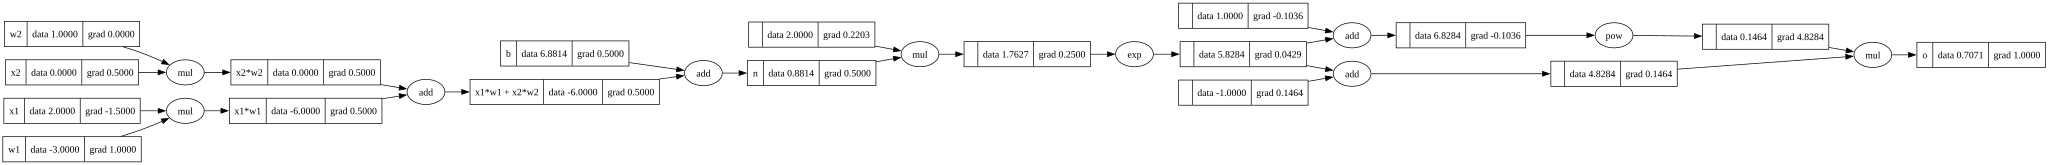

✅ 1. BİZİM 'Value' MOTORUMUZUN SONUÇLARI
x1 grad: -1.5000 | w1 grad: 1.0000
x2 grad: 0.5000 | w2 grad: 0.0000

✅ 2. PYTORCH İLE DOĞRULAMA (Aynı İşlem)
x1 grad: -1.5000 | w1 grad: 1.0000
x2 grad: 0.5000 | w2 grad: 0.0000

✅ 3. SAYISAL (NUMERICAL) TÜREV İLE DOĞRULAMA
x1 grad: -1.5032 | w1 grad: 0.9986
x2 grad: 0.4996 | w2 grad: 0.0000


In [9]:
# Görev 4: tanh'ı parçala: 
    # exp, bölme ve pow operasyonlarını ekle, aynı gradient'leri aldığını göster. 
    # Sonra doğrula: aynı ifadeyi aynı değerlerle 
        # hem backward() ile 
        # hem geçen haftaki numerical derivative ile 
        # hem de PyTorch ile hesapla, 
            # üçünün eşleştiğini göster.

class Value:
    def __init__(self, data, elements=(), ops="", label=''):
        self.data = data
        self.elements = elements
        self.ops = ops
        self.label = label

        self.grad = 0.0
        self._backward = lambda:None
    
    def __repr__(self):
        return f"{self.data}"

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        output = Value(self.data + other.data, (self, other), "add")

        def _backward():
            self.grad  += 1.0 * output.grad
            other.grad += 1.0 * output.grad
        output._backward = _backward

        return output
    
    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        output = Value(self.data * other.data, (self, other), "mul")

        def _backward():
            self.grad  += other.data * output.grad
            other.grad += self.data  * output.grad
        output._backward = _backward

        return output
    

    def tanh(self):
        import math
        x = self.data 
        tan_output = (math.exp(2*x) - 1) / (math.exp(2*x) + 1)
        output = Value(data=tan_output, elements=(self, ), ops="tanh")

        def _backward():
            # activation bu, other olmaz
            self.grad += (1 - tan_output ** 2) * output.grad
        output._backward = _backward

        return output
    
    # YENİ EKLENDİ
    def exp(self):
        import math
        x = self.data
        output = Value(math.exp(x), elements=(self,), ops="exp")

        def _backward():
            self.grad += output.data * output.grad
        output._backward = _backward

        return output
    
    # YENİ EKLENDİ
    def __pow__(self, other):
        assert isinstance(other, (int, float)), "Sadece int/float üs destekleniyor"
        #other = other if isinstance(other, Value) else Value(other)
        output = Value(self.data ** other, elements=(self,), ops="pow")
    

        def _backward():
            self.grad += other * (self.data ** (other - 1)) * output.grad
        output._backward = _backward

        return output
    
    # YENİ EKLENDİ
        # NEDEN??
            # bölmenin türevi uğraştırıcı
            # bölme -> "çarpma + pow" yapıyoruz 
                # daha kolay oluyor
                # ayrıca, ondan _backward() yazmadık... pow ve mul a handle ettik
    def __truediv__(self, other):
        return self * other**-1

    # YENİ EKLENDİ (Sağdan çarpma: 2 * n durumu için)
    def __rmul__(self, other): 
        return self * other

    # YENİ EKLENDİ (Çıkarma işlemi: e - 1 durumu için)
    def __sub__(self, other): 
        return self + (other * -1)

    
    def backward(self):
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v.elements:
                    build_topo(child)
                topo.append(v)
        build_topo(self)

        self.grad = 1.0
        for node in reversed(topo):
            node._backward()



# exp, bölme, pow testi
# ------------------------
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1, w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'

e = (2*n).exp()
o = (e - 1) / (e + 1)

o.label = 'o'
o.backward()
display(draw_dot(o))


print("=========================================")
print("✅ 1. BİZİM 'Value' MOTORUMUZUN SONUÇLARI")
print(f"x1 grad: {x1.grad:.4f} | w1 grad: {w1.grad:.4f}")
print(f"x2 grad: {x2.grad:.4f} | w2 grad: {w2.grad:.4f}")


print("\n=========================================")
print("✅ 2. PYTORCH İLE DOĞRULAMA (Aynı İşlem)")
import torch

# PyTorch'ta her şey tensör'dür. requires_grad=True diyerek türev izlemeyi açıyoruz.
# double() yapıyoruz ki PyTorch 64-bit hassasiyetle hesaplasın (bizim Value gibi)
x1_t = torch.Tensor([2.0]).double(); x1_t.requires_grad = True
x2_t = torch.Tensor([0.0]).double(); x2_t.requires_grad = True
w1_t = torch.Tensor([-3.0]).double(); w1_t.requires_grad = True
w2_t = torch.Tensor([1.0]).double(); w2_t.requires_grad = True
b_t  = torch.Tensor([6.8813735870195432]).double(); b_t.requires_grad = True

n_t = x1_t*w1_t + x2_t*w2_t + b_t
e_t = (2*n_t).exp()
o_t = (e_t - 1) / (e_t + 1)

# PyTorch'un kendi backprop'u! Bizim yazdığımız o.backward() ile tamamen aynı işlemi yapıyormuş ama
o_t.backward() 

print(f"x1 grad: {x1_t.grad.item():.4f} | w1 grad: {w1_t.grad.item():.4f}")
print(f"x2 grad: {x2_t.grad.item():.4f} | w2 grad: {w2_t.grad.item():.4f}")


print("\n=========================================")
print("✅ 3. SAYISAL (NUMERICAL) TÜREV İLE DOĞRULAMA")
# f(x+h) - f(x) / h mantığı
import math
def eval_o(x1_val, w1_val, x2_val, w2_val, b_val):
    n_v = x1_val*w1_val + x2_val*w2_val + b_val
    e_v = math.exp(2 * n_v)
    return (e_v - 1) / (e_v + 1)

h = 0.001
o_normal = eval_o(2.0, -3.0, 0.0, 1.0, 6.8813735870195432)

# HER BİRİ İÇİN AYRI AYRI +h VERİYORUZ
o_x1_artis = eval_o(2.0 + h, -3.0, 0.0, 1.0, 6.8813735870195432)
o_w1_artis = eval_o(2.0, -3.0 + h, 0.0, 1.0, 6.8813735870195432)
o_x2_artis = eval_o(2.0, -3.0, 0.0 + h, 1.0, 6.8813735870195432)
o_w2_artis = eval_o(2.0, -3.0, 0.0, 1.0 + h, 6.8813735870195432)

# TÜREVLERİNİ HESAPLIYORUZ (Fark / h)
x1_grad_num = (o_x1_artis - o_normal) / h
w1_grad_num = (o_w1_artis - o_normal) / h
x2_grad_num = (o_x2_artis - o_normal) / h
w2_grad_num = (o_w2_artis - o_normal) / h

print(f"x1 grad: {x1_grad_num:.4f} | w1 grad: {w1_grad_num:.4f}")
print(f"x2 grad: {x2_grad_num:.4f} | w2 grad: {w2_grad_num:.4f}")


Adım 0: Loss = 7.1882
Adım 1: Loss = 6.1852
Adım 2: Loss = 5.1814
Adım 3: Loss = 4.0891
Adım 4: Loss = 3.2373
Adım 5: Loss = 2.7385
Adım 6: Loss = 2.3993
Adım 7: Loss = 2.0889
Adım 8: Loss = 1.7346
Adım 9: Loss = 1.3229
Adım 10: Loss = 0.9215
Adım 11: Loss = 0.6210
Adım 12: Loss = 0.4326
Adım 13: Loss = 0.3182
Adım 14: Loss = 0.2459
Adım 15: Loss = 0.1975
Adım 16: Loss = 0.1634
Adım 17: Loss = 0.1385
Adım 18: Loss = 0.1196
Adım 19: Loss = 0.1048


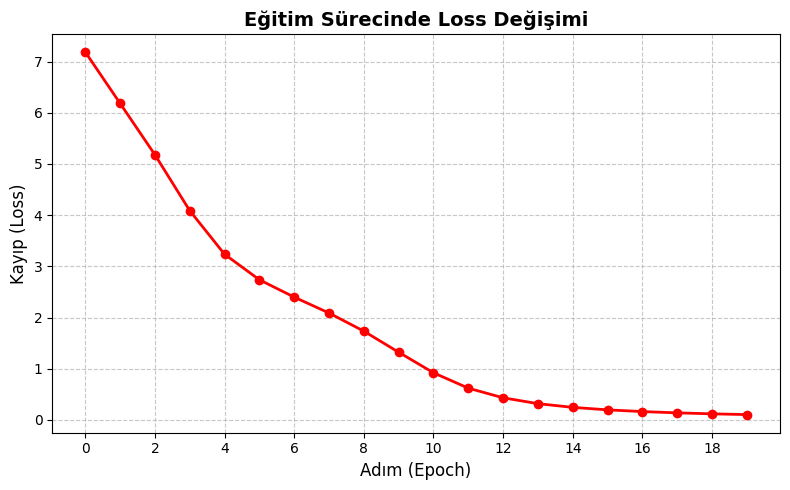

In [10]:
# Görev 5:
    # Neuron, Layer ve MLP sınıflarını kur
    # Parametreleri tek listede topla
    # videodaki küçük veri setiyle eğit
    # loss'un adım adım düştüğünü göster
        # Her adımda gradient'leri sıfırlamayı unutma, videodaki meşhur bug.
import random
from sympy.simplify import hyperexpand


class Neuron:
    def __init__(self, nin):
        # nin -> number of input neurons
            # w'da, o (her bir) input neuron'ların weight'leri
        self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1,1))
    
    def __call__(self, x):
        # x, burda bir list... her bir "arkadaki" neuron, bir x
        # w'lar da, her bir arkadaki neuron'un (x ile multiply olacak) weight'ler

        act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
        out = act.tanh()

        return out
    
    def parameters(self):
        return self.w + [self.b]

class Layer:
    def __init__(self, nin, nout):
        # nout, kaç tane output veren neuron var?
            # nin, "bize (arkadan) gelen kaç neuron var?"a bakıyordu
            # bu da, "bizden (öne) kaç neuron gidiyor?"u verir
        self.neurons = [Neuron(nin) for _ in range(nout)]
    
    def __call__(self, x):
        # => e burda, dimension artmaz mı?
            # [ [inputs of n1], [inputs of n2], ...]
        # artmaz, çünkü burda tüm inputlar, tüm output'lara bağlı
            # her input, farklı şekillerde bağlanmıyor
            # [ [inputs to all neurons] ] gibi
        # n(x) ile de, class Neuron'daki __call__() çalışmış olur
        outputs = [n(x) for n in self.neurons]
        return outputs[0] if len(outputs) == 1 else outputs

    def parameters(self):
        return [p for n in self.neurons for p in n.parameters()]


class MLP:
    def __init__(self, nin, nouts):
        # nouts... nout değil !!!
            # nout, 1 katman için "o katmandaki nöron sayısı" idi
                # sayı idi
            # nouts, bir liste
                # her katmanda, kaç nöron var listesi
                    # [4,1,2] gibi
        # nin
            # ilk katmandaki input layer'daki nöron sayısı
        a = [nin] + nouts
        # burdaki trick şu:
            # -> nin de layer değil mi? 
            # diğer layerlara ekliyo
                # 3 + [4,1,2] = [3,4,1,2]

        self.layers = [Layer(a[i], a[i+1]) for i in range(len(nouts))]
        # 0. layer a[0] -> 1.layer a[1]
                #  [3,4,1,2] idi ya
            # 3->4
        # 1. layer a[1] -> 2.layer a[2]
                #  [3,4,1,2] idi ya
            # 4->1 
        # 2. layer a[2] -> 3.layer a[3]
                #  [3,4,1,2] idi ya
            # 1->2
        
    
    def __call__(self, x):
        # x, input verisi
        for layer in self.layers:
            x = layer(x)
        return x
    
    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]


# model
n = MLP(3, [4,4,1])

# tiny dataset
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0],
]

ys = [1.0, -1.0, -1.0, 1.0]

# training
def train():
    losses = []
    for i in range(20):
        # forward pass
        ypred = [n(x) for x in xs]
        loss = sum(((yout - ygt)**2 for ygt, yout in zip(ys, ypred)), Value(0.0))  

        # backward pass 
        for p in n.parameters():
            # zero grad -> update'ler birikmemeli...
            p.grad = 0.0
        loss.backward()

        # update
        for p in n.parameters():
            p.data += -0.05 * p.grad
        
        # O anki loss'un .data değerini listeye ekliyoruz
        losses.append(loss.data)
        print(f"Adım {i}: Loss = {loss.data:.4f}")
        
    # --- EĞİTİM BİTTİKTEN SONRA GRAFİK ÇİZİMİ ---
    # DİKKAT: Burası for döngüsünün DIŞINDA olmalı! (Girintiye dikkat edin)
    plt.figure(figsize=(8, 5))
    plt.plot(range(20), losses, marker='o', color='red', linestyle='-', linewidth=2)
    plt.title("Eğitim Sürecinde Loss Değişimi", fontsize=14, fontweight='bold')
    plt.xlabel("Adım (Epoch)", fontsize=12)
    plt.ylabel("Kayıp (Loss)", fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.xticks(range(0, 20, 2))  # x ekseni adımlarını ayarla
    plt.tight_layout()
    plt.show()

train()


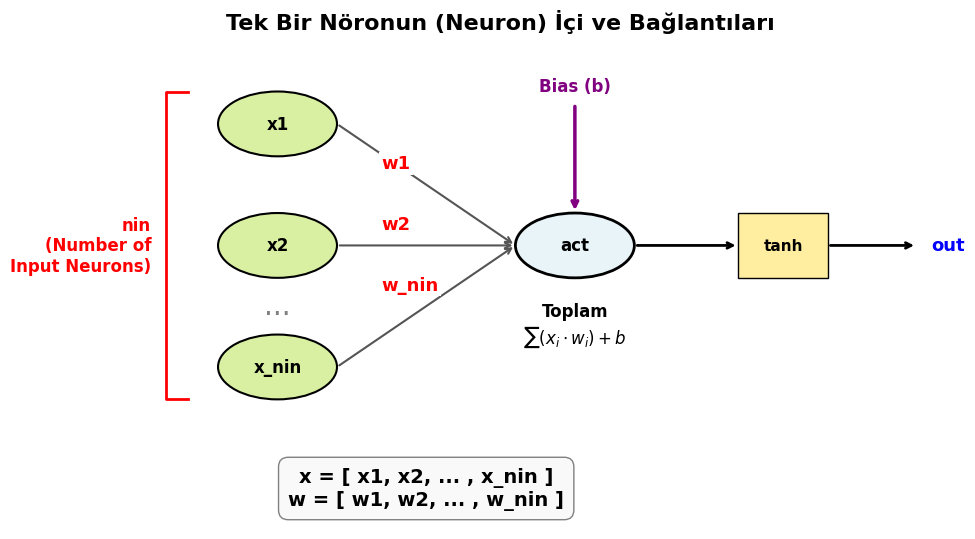

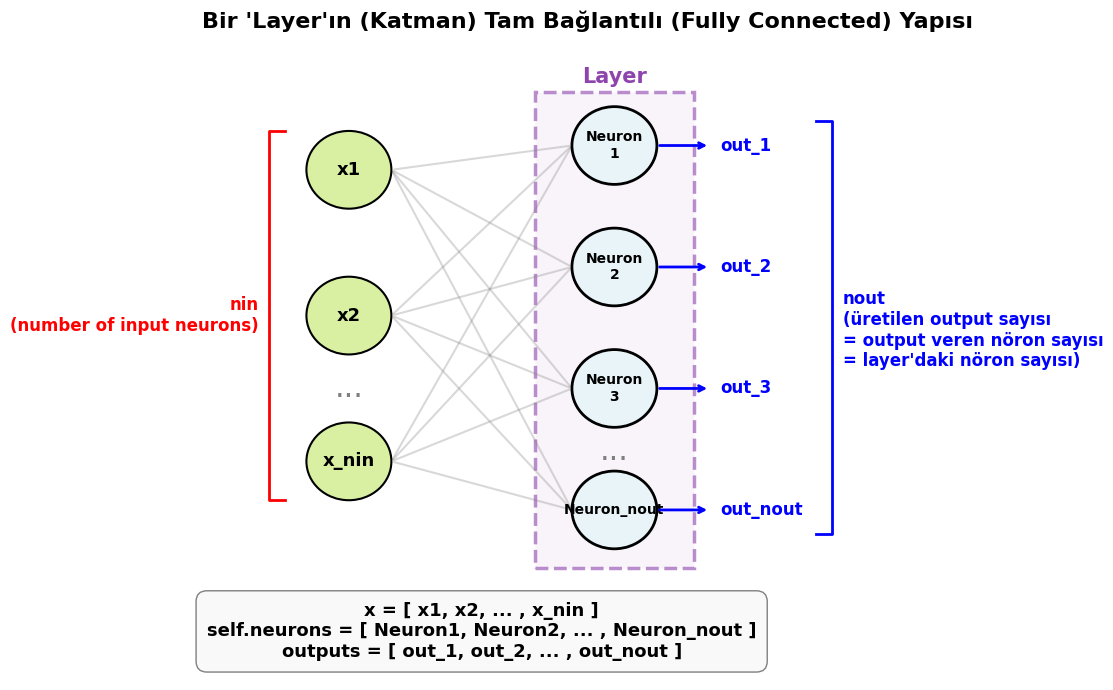

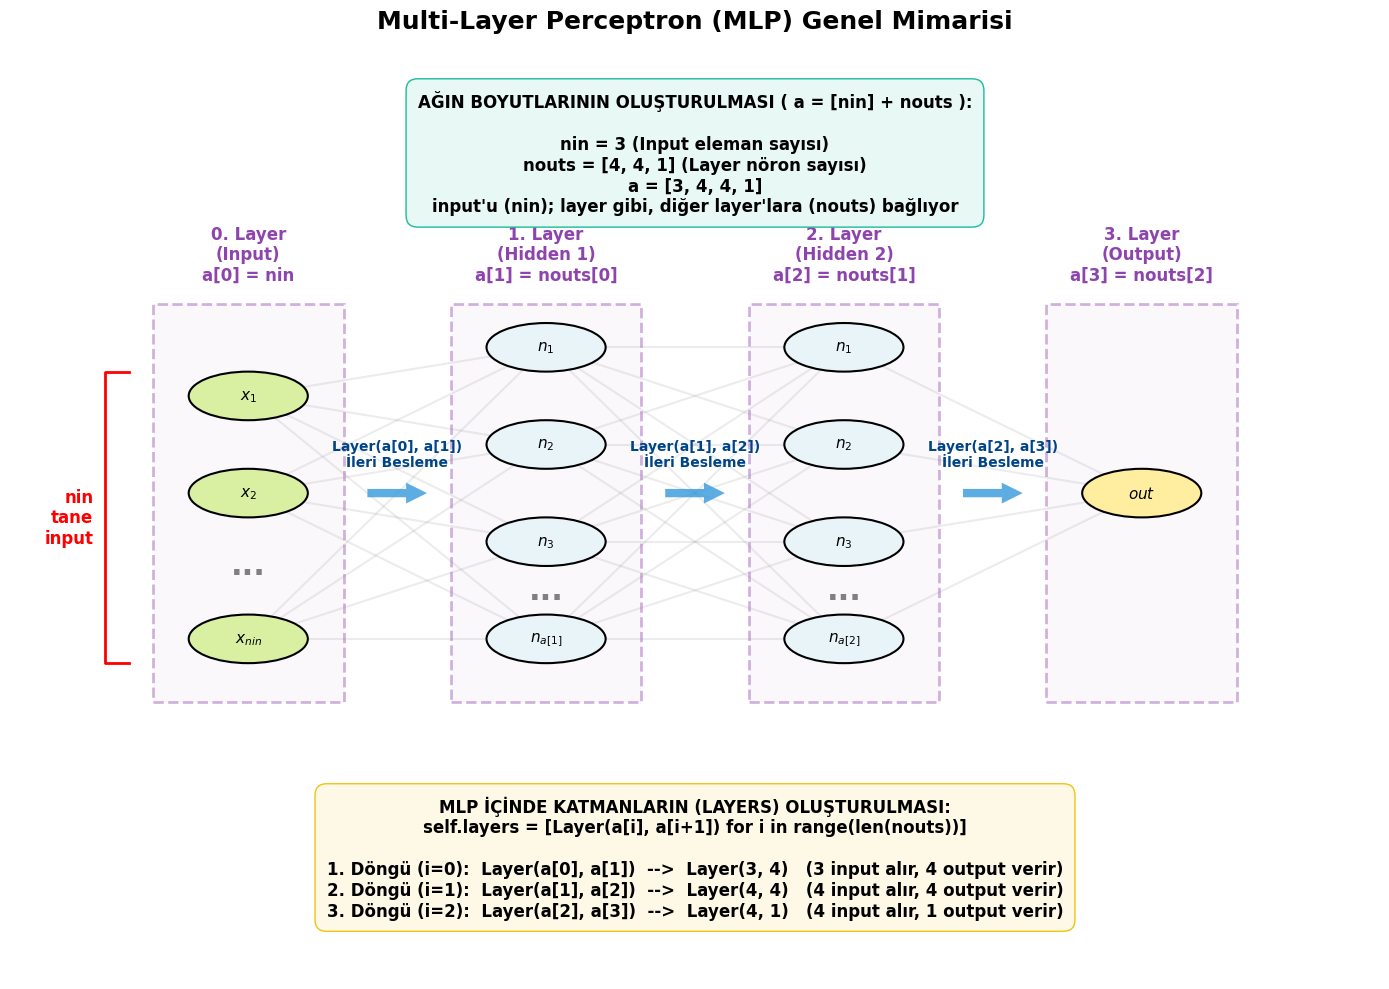

In [11]:
# görselleştirme

import matplotlib.pyplot as plt
import matplotlib.patches as patches

def noron_mimarisi_gorseli(nin="nin"):
    fig, ax = plt.subplots(figsize=(10, 5.5))
    
    # Merkez Koordinatlar
    x_in = 0.3
    x_neuron = 0.7
    y_neuron = 0.5
    
    y_inputs = [0.8, 0.5, 0.2]
    labels_x = ["x1", "x2", f"x_{nin}"]
    labels_w = ["w1", "w2", f"w_{nin}"]
    
    # Nöron (Daire - BOYUTU KÜÇÜLTÜLDÜ)
    circle = patches.Circle((x_neuron, y_neuron), 0.08, edgecolor='black', facecolor='#e8f4f8', lw=2, zorder=3)
    ax.add_patch(circle)
    ax.text(x_neuron, y_neuron, "act", ha='center', va='center', fontsize=12, fontweight='bold')
    
    # Formülü dairenin altına aldık
    ax.text(x_neuron, y_neuron - 0.14, "Toplam\n$\sum (x_i \cdot w_i) + b$", ha='center', va='top', fontsize=12, fontweight='bold')
    
    # Bias (b) oku (Bağlantı noktası yeni boyuta uyarlandı)
    ax.annotate("", xy=(x_neuron, y_neuron+0.08), xytext=(x_neuron, y_neuron+0.35),
                arrowprops=dict(arrowstyle="->", color="purple", lw=2.5))
    ax.text(x_neuron, y_neuron+0.38, "Bias (b)", color="purple", ha='center', fontsize=12, fontweight='bold')
    
    # Girdiler (Input Düğümleri) ve Ağırlık (Weight) Okları
    for i, y in enumerate(y_inputs):
        if i == 2: 
            ax.text(x_in, 0.35, "...", ha='center', va='center', fontsize=20, color='gray')
            
        in_circle = patches.Circle((x_in, y), 0.08, edgecolor='black', facecolor='#d9f0a3', lw=1.5, zorder=3)
        ax.add_patch(in_circle)
        ax.text(x_in, y, labels_x[i], ha='center', va='center', fontsize=12, fontweight='bold')
        
        # w okları (Artık x_neuron - 0.08'e gidiyor)
        ax.annotate("", xy=(x_neuron-0.08, y_neuron), xytext=(x_in+0.08, y),
                    arrowprops=dict(arrowstyle="->", color="#555", lw=1.5), zorder=1)
        
        # Ağırlık yazıları
        mid_x = (x_in + x_neuron) / 2
        mid_y = (y + y_neuron) / 2
        ax.text(mid_x - 0.06, mid_y + 0.04, labels_w[i], color="red", fontsize=13, fontweight='bold',
                bbox=dict(facecolor='white', edgecolor='none', pad=1.5))
    
    # SOL TARAFA BOYUT BELİRTECİ [nin TANE]
    br_x = x_in - 0.12
    ax.plot([br_x, br_x - 0.03, br_x - 0.03, br_x], [0.88, 0.88, 0.12, 0.12], color='red', lw=2)
    ax.text(br_x - 0.05, 0.5, "nin\n(Number of\nInput Neurons)", color='red', ha='right', va='center', fontweight='bold', fontsize=12)

    # Çıkış Oku (act'den tanh'a)
    ax.annotate("", xy=(x_neuron+0.22, y_neuron), xytext=(x_neuron+0.08, y_neuron),
                arrowprops=dict(arrowstyle="->", color="black", lw=2))
    
    # Tanh kutusu (Daire ile tamamen aynı hizada ve boyutta)
    tanh_box = patches.Rectangle((x_neuron+0.22, y_neuron-0.08), 0.12, 0.16, edgecolor='black', facecolor='#ffeda0', zorder=3)
    ax.add_patch(tanh_box)
    ax.text(x_neuron+0.28, y_neuron, "tanh", ha='center', va='center', fontsize=11, fontweight='bold')
    
    # En son çıkış oku ve "out"
    ax.annotate("", xy=(x_neuron+0.46, y_neuron), xytext=(x_neuron+0.34, y_neuron),
                arrowprops=dict(arrowstyle="->", color="black", lw=2))
    ax.text(x_neuron+0.48, y_neuron, "out", ha='left', va='center', fontsize=13, fontweight='bold', color='blue')
    
    # ALT KISMA AÇIKLAMA
    alt_yazi = f"x = [ x1, x2, ... , x_{nin} ]\nw = [ w1, w2, ... , w_{nin} ]"
    ax.text(0.5, -0.1, alt_yazi, ha='center', va='center', fontsize=14, fontweight='bold', 
            bbox=dict(facecolor='#f9f9f9', edgecolor='gray', boxstyle='round,pad=0.5'))
    
    ax.set_xlim(0, 1.2)
    ax.set_ylim(-0.2, 1)
    ax.axis('off')
    plt.title(f"Tek Bir Nöronun (Neuron) İçi ve Bağlantıları", fontsize=16, fontweight='bold', pad=10)
    plt.tight_layout()
    plt.show()


def layer_mimarisi_gorseli():
    fig, ax = plt.subplots(figsize=(11, 7))
    
    # Koordinatlar
    x_in = 0.25
    x_layer = 0.75
    
    y_in = [0.8, 0.5, 0.2]
    labels_in = ["x1", "x2", "x_nin"]
    
    y_layer = [0.85, 0.6, 0.35, 0.1]
    labels_layer = ["Neuron 1", "Neuron 2", "Neuron 3", "Neuron_nout"]
    
    # 1. TÜM BAĞLANTILARI (FULLY CONNECTED AĞ) ÇİZ
    # Dikkat: Her x, her Nörona gidiyor!
    for i, yi in enumerate(y_in):
        for j, yj in enumerate(y_layer):
            ax.annotate("", xy=(x_layer-0.08, yj), xytext=(x_in+0.08, yi),
                        arrowprops=dict(arrowstyle="-", color="gray", alpha=0.3, lw=1.5), zorder=1)

    # 2. GİRDİLER (INPUTS)
    for i, y in enumerate(y_in):
        if i == 2:
            ax.text(x_in, 0.35, "...", ha='center', va='center', fontsize=22, color='gray')
            
        in_circle = patches.Circle((x_in, y), 0.08, edgecolor='black', facecolor='#d9f0a3', lw=1.5, zorder=3)
        ax.add_patch(in_circle)
        ax.text(x_in, y, labels_in[i], ha='center', va='center', fontsize=13, fontweight='bold')
        
    # nin Belirteci (Sol bracket)
    br_in_x = x_in - 0.12
    ax.plot([br_in_x, br_in_x - 0.03, br_in_x - 0.03, br_in_x], [0.88, 0.88, 0.12, 0.12], color='red', lw=2)
    ax.text(br_in_x - 0.05, 0.5, "nin\n(number of input neurons)", color='red', ha='right', va='center', fontweight='bold', fontsize=12)

    # LAYER DİKDÖRTGENİ (Tüm nöronları içine alan)
    layer_box = patches.Rectangle((x_layer - 0.15, -0.02), 0.30, 0.98, linewidth=2.5, edgecolor='#8e44ad', facecolor='#f5eef8', alpha=0.6, linestyle='--', zorder=0)
    ax.add_patch(layer_box)
    ax.text(x_layer, 0.99, "Layer", ha='center', va='center', fontsize=15, fontweight='bold', color='#8e44ad')

    # 3. NÖRONLAR (LAYER)
    for j, y in enumerate(y_layer):
        if j == 3:
            ax.text(x_layer, 0.22, "...", ha='center', va='center', fontsize=22, color='gray')
            
        neuron_circle = patches.Circle((x_layer, y), 0.08, edgecolor='black', facecolor='#e8f4f8', lw=2, zorder=3)
        ax.add_patch(neuron_circle)
        # Nöron isimlerini ortalayarak yazalım
        isim = labels_layer[j].replace(" ", "\n")
        ax.text(x_layer, y, isim, ha='center', va='center', fontsize=10, fontweight='bold')
        
        # Çıkış okları
        ax.annotate("", xy=(x_layer+0.18, y), xytext=(x_layer+0.08, y),
                    arrowprops=dict(arrowstyle="->", color="blue", lw=2))
        
        out_label = f"out_1" if j==0 else (f"out_2" if j==1 else (f"out_3" if j==2 else "out_nout"))
        ax.text(x_layer+0.2, y, out_label, ha='left', va='center', color='blue', fontweight='bold', fontsize=12)

    # nout Belirteci (Sağ bracket)
    br_out_x = x_layer + 0.38
    ax.plot([br_out_x, br_out_x + 0.03, br_out_x + 0.03, br_out_x], [0.9, 0.9, 0.05, 0.05], color='blue', lw=2)
    ax.text(br_out_x + 0.05, 0.47, "nout\n(üretilen output sayısı\n= output veren nöron sayısı\n= layer'daki nöron sayısı)", color='blue', ha='left', va='center', fontweight='bold', fontsize=12)

    # 5. ALT KISMA LİSTE AÇIKLAMALARI
    alt_yazi = (
        "x = [ x1, x2, ... , x_nin ]\n"
        "self.neurons = [ Neuron1, Neuron2, ... , Neuron_nout ]\n"
        "outputs = [ out_1, out_2, ... , out_nout ]"
    )
    ax.text(0.5, -0.15, alt_yazi, ha='center', va='center', fontsize=13, fontweight='bold', 
            bbox=dict(facecolor='#f9f9f9', edgecolor='gray', boxstyle='round,pad=0.6'))
    
    ax.set_xlim(0, 1.4)
    ax.set_ylim(-0.25, 1.05)
    ax.axis('off')
    plt.title("Bir 'Layer'ın (Katman) Tam Bağlantılı (Fully Connected) Yapısı", fontsize=16, fontweight='bold', pad=15)
    plt.tight_layout()
    plt.show()


def mlp_mimarisi_gorseli():
    fig, ax = plt.subplots(figsize=(14, 10))
    
    # Katmanların koordinatları ve isimleri
    layers_data = [
        {
            "x": 0.15, 
            "y": [0.75, 0.55, 0.25], 
            "labels": ["$x_1$", "$x_2$", "$x_{nin}$"], 
            "color": "#d9f0a3", 
            "name": "0. Layer\n(Input)\na[0] = nin"
        },
        {
            "x": 0.4, 
            "y": [0.85, 0.65, 0.45, 0.25], 
            "labels": ["$n_1$", "$n_2$", "$n_3$", "$n_{a[1]}$"], 
            "color": "#e8f4f8", 
            "name": "1. Layer\n(Hidden 1)\na[1] = nouts[0]"
        },
        {
            "x": 0.65, 
            "y": [0.85, 0.65, 0.45, 0.25], 
            "labels": ["$n_1$", "$n_2$", "$n_3$", "$n_{a[2]}$"], 
            "color": "#e8f4f8", 
            "name": "2. Layer\n(Hidden 2)\na[2] = nouts[1]"
        },
        {
            "x": 0.9, 
            "y": [0.55], 
            "labels": ["$out$"], 
            "color": "#ffeda0", 
            "name": "3. Layer\n(Output)\na[3] = nouts[2]"
        }
    ]

    # Zayıf bağlantı çizgileri (arka planda, Fully Connected yapıyı anımsatmak için)
    for i in range(len(layers_data)-1):
        x_start = layers_data[i]["x"]
        y_starts = layers_data[i]["y"]
        x_end = layers_data[i+1]["x"]
        y_ends = layers_data[i+1]["y"]
        for ys in y_starts:
            for ye in y_ends:
                ax.plot([x_start, x_end], [ys, ye], color="gray", alpha=0.15, lw=1.5, zorder=1)

    # Nöronları ve Katman (Layer) Kutularını Çizme
    for d in layers_data:
        x = d["x"]
        # Katman çerçevesi (Boydan boya dikdörtgen)
        rect = patches.Rectangle((x - 0.08, 0.12), 0.16, 0.82, linewidth=2, edgecolor='#8e44ad', facecolor='#f5eef8', alpha=0.4, linestyle='--', zorder=0)
        ax.add_patch(rect)
        
        # Katman başlığı
        ax.text(x, 0.98, d["name"], ha='center', va='bottom', fontsize=12, fontweight='bold', color='#8e44ad')
        
        # Daireler (Nöronlar)
        for i, y in enumerate(d["y"]):
            circle = patches.Circle((x, y), 0.05, edgecolor='black', facecolor=d["color"], lw=1.5, zorder=3)
            ax.add_patch(circle)
            ax.text(x, y, d["labels"][i], ha='center', va='center', fontsize=11, fontweight='bold')
            
            # Araya 3 nokta koyma
            if i == len(d["y"]) - 2:
                mid_y = (d["y"][i] + d["y"][i+1]) / 2
                ax.text(x, mid_y, "...", ha='center', va='center', fontsize=22, color='gray', fontweight='bold')

    # Katmanlar Arası Geçiş Okları ve Operasyon Metinleri
    for i in range(len(layers_data)-1):
        x_start = layers_data[i]["x"] + 0.1
        x_end = layers_data[i+1]["x"] - 0.1
        mid_x = (x_start + x_end) / 2
        
        # Kalın mavi ok
        ax.annotate("", xy=(x_end, 0.55), xytext=(x_start, 0.55),
                    arrowprops=dict(facecolor="#3498db", edgecolor="none", width=6, headwidth=15, headlength=15, alpha=0.8), zorder=2)
                    
        op_text = f"Layer(a[{i}], a[{i+1}])\nİleri Besleme"
        ax.text(mid_x, 0.6, op_text, ha='center', va='bottom', fontsize=10, fontweight='bold', color='#004488', zorder=5)

    # nin Belirteci (Sol kırmızı bracket)
    br_in_x = 0.15 - 0.1
    ax.plot([br_in_x, br_in_x - 0.02, br_in_x - 0.02, br_in_x], [0.8, 0.8, 0.2, 0.2], color='red', lw=2)
    ax.text(br_in_x - 0.03, 0.5, "nin\ntane\ninput", color='red', ha='right', va='center', fontweight='bold', fontsize=12)

    # Üst Açıklama
    top_text = (
        "AĞIN BOYUTLARININ OLUŞTURULMASI ( a = [nin] + nouts ):\n\n"
        "nin = 3 (Input eleman sayısı)\n"
        "nouts = [4, 4, 1] (Layer nöron sayısı)\n"
        "a = [3, 4, 4, 1]\n"
        "input'u (nin); layer gibi, diğer layer'lara (nouts) bağlıyor"
    )
    ax.text(0.525, 1.25, top_text, ha='center', va='center', fontsize=12, fontweight='bold', 
            bbox=dict(facecolor='#e8f8f5', edgecolor='#1abc9c', boxstyle='round,pad=0.7'))
            
    # Alt Açıklama
    bottom_text = (
        "MLP İÇİNDE KATMANLARIN (LAYERS) OLUŞTURULMASI:\n"
        "self.layers = [Layer(a[i], a[i+1]) for i in range(len(nouts))]\n\n"
        "1. Döngü (i=0):  Layer(a[0], a[1])  -->  Layer(3, 4)   (3 input alır, 4 output verir)\n"
        "2. Döngü (i=1):  Layer(a[1], a[2])  -->  Layer(4, 4)   (4 input alır, 4 output verir)\n"
        "3. Döngü (i=2):  Layer(a[2], a[3])  -->  Layer(4, 1)   (4 input alır, 1 output verir)"
    )
    ax.text(0.525, -0.2, bottom_text, ha='center', va='center', fontsize=12, fontweight='bold', 
            bbox=dict(facecolor='#fef9e7', edgecolor='#f1c40f', boxstyle='round,pad=0.7'))

    ax.set_xlim(-0.05, 1.1)
    ax.set_ylim(-0.45, 1.45)
    ax.axis('off')
    plt.title("Multi-Layer Perceptron (MLP) Genel Mimarisi", fontsize=18, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.show()

# Tüm görselleri arka arkaya aynı hücrede üretelim
noron_mimarisi_gorseli()
layer_mimarisi_gorseli()
mlp_mimarisi_gorseli()


In [12]:
görev 1'de "self.elements" kısmında

self.elements = elements yerine self.elements = set(elements) kalabilridi
* kendi versionum olsun diye böyle bıraktım

- return Value(self.data + other.data, (self.data, other.data), "add")
+ return Value(self.data + other.data, (self, other), "add")


mul kısmında, * yerine + kalmış
    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        output = Value(self.data + other.data, (self, other), "mul")


görev 3
def _backward(self, other) yazmak * yazmaamk gerekiyor
+= yerine = demek, grad hesaplarken
a.grad = 1.0 * out_grad dedim mesela... += olmalı


"x1w1, x2w2, x1w1x2w2"yi, "x1*w1, x2*w2, x1*w1*x2*w2" sanmak
* bunlar, "a,b,c" gibi random isimler... türevi alınabilen çarpma değil



görev 5
x = [2.0, 3.0] deyince:
* aslında, 2 input neuron var, bir input'un değeri 2.0, diğerinin değeri 3.0 imiş
* ben, direkt o asıl neuron'umuzun kendisi, [2.0, 3.0] vektörünü değer olarak tutuyor sandım

mlp class'ında __call__'da, for loop içinde:
x = layer(x) yerine += dedim

layer class'ında, def paramters()'ta:
params = [neuron.parameters() for neuron in self.neurons] yapmıştım ben
-> [ [w1, w2, b1], [w3, w4, b2] ] tarzı oldu liste... flatten olmalı

SyntaxError: unterminated string literal (detected at line 1) (3184078732.py, line 1)